# Product Analysis

This notebook analyzes product characteristics, sales performance, and shipping-related relationships in the Olist e-commerce dataset using PostgreSQL.

The analysis focuses on:

- Product name and description length
- Product dimensions and weight by category
- Average product volume by category
- Correlations between freight value and product characteristics
- Relationship between units sold and photo quantity
- Linear relationship between freight value and product weight

All analytical calculations are performed in SQL, while Python is used for data retrieval and visualization.

In [1]:
import getpass
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

password = getpass.getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="laraolgun",
    password=password,
    host="localhost",
    database="olist"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL: olist")

Connected to PostgreSQL: olist


## 1. Average Product Name and Description Length by Category

In [7]:
query = """
SELECT
    product_category,
    ROUND(AVG(product_name_length)::numeric, 2) AS avg_name_length,
    ROUND(AVG(product_desc_length)::numeric, 2) AS avg_description_length
FROM products
WHERE product_category IS NOT NULL
GROUP BY product_category
ORDER BY avg_name_length, avg_description_length;
"""

df_product_text = pd.read_sql_query(query, engine)

df_product_text

,product_category,avg_name_length,avg_description_length
0,fashion_roupa_masculina,39.65,627.39
1,fashion_roupa_feminina,40.22,638.78
2,livros_interesse_geral,40.28,988.59
3,livros_tecnicos,41.97,1351.53
4,moveis_colchao_e_estofado,43.20,1111.30
...,...,...,...
68,tablets_impressao_imagem,54.00,676.44
69,portateis_cozinha_e_preparadores_de_alimentos,54.40,623.20
70,eletrodomesticos,54.48,404.60
71,pcs,55.53,2128.83


## 2. Average Product Weight and Dimensions by Category

In [8]:
query = """
SELECT
    product_category,
    ROUND((AVG(product_weight_grams) / 1000.0)::numeric, 2) AS avg_weight_kg,
    ROUND(AVG(product_length_cm)::numeric, 2) AS avg_length_cm,
    ROUND(AVG(product_height_cm)::numeric, 2) AS avg_height_cm,
    ROUND(AVG(product_width_cm)::numeric, 2) AS avg_width_cm
FROM products
WHERE product_category IS NOT NULL
GROUP BY product_category
ORDER BY avg_weight_kg DESC;
"""

df_product_dimensions = pd.read_sql_query(query, engine)

df_product_dimensions

,product_category,avg_weight_kg,avg_length_cm,avg_height_cm,avg_width_cm
0,moveis_colchao_e_estofado,13.19,46.30,34.40,41.30
1,moveis_escritorio,12.74,55.63,41.86,37.92
2,moveis_cozinha_area_de_servico_jantar_e_jardim,11.60,47.34,40.48,38.68
3,moveis_quarto,10.00,59.93,30.80,34.40
4,eletrodomesticos_2,9.91,45.73,30.67,38.17
...,...,...,...,...,...
68,dvds_blu_ray,0.38,21.27,4.42,14.88
69,fashion_underwear_e_moda_praia,0.36,25.51,8.85,18.91
70,fashion_esporte,0.34,22.11,12.84,16.26
71,fashion_roupa_infanto_juvenil,0.32,27.40,13.40,20.60


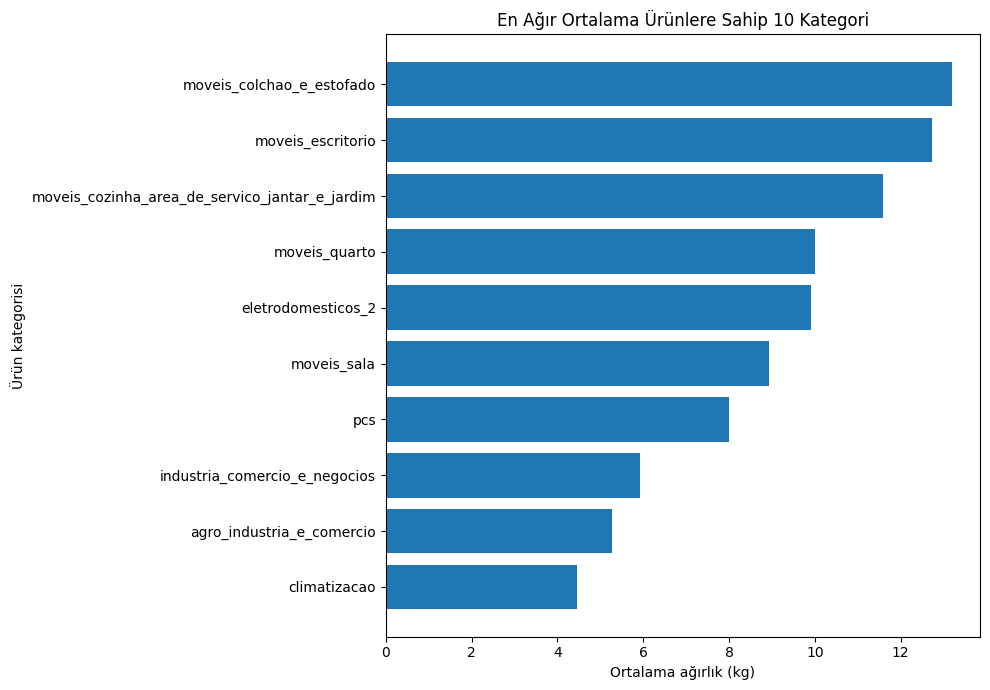

In [9]:
query = """
SELECT
    product_category,
    ROUND((AVG(product_weight_grams) / 1000.0)::numeric, 2) AS avg_weight_kg
FROM products
WHERE product_category IS NOT NULL
  AND product_weight_grams IS NOT NULL
GROUP BY product_category
ORDER BY avg_weight_kg DESC
LIMIT 10;
"""

df_weight = pd.read_sql_query(query, engine)

plt.figure(figsize=(10, 7))

plt.barh(
    df_weight["product_category"][::-1],
    df_weight["avg_weight_kg"][::-1]
)

plt.xlabel("Ortalama ağırlık (kg)")
plt.ylabel("Ürün kategorisi")
plt.title("En Ağır Ortalama Ürünlere Sahip 10 Kategori")

plt.tight_layout()
plt.show()

## 3. Average Product Volume by Category

In [10]:
query = """
SELECT
    product_category,
    ROUND(
        AVG(
            product_length_cm::numeric
            * product_height_cm
            * product_width_cm
        ),
        2
    ) AS avg_volume_cm3
FROM products
WHERE product_category IS NOT NULL
  AND product_length_cm IS NOT NULL
  AND product_height_cm IS NOT NULL
  AND product_width_cm IS NOT NULL
GROUP BY product_category
ORDER BY avg_volume_cm3 DESC;
"""

df_product_volume = pd.read_sql_query(query, engine)

df_product_volume

,product_category,avg_volume_cm3
0,moveis_colchao_e_estofado,77244.30
1,moveis_escritorio,75468.47
2,moveis_cozinha_area_de_servico_jantar_e_jardim,69406.10
3,eletrodomesticos_2,55476.31
4,moveis_sala,54486.13
...,...,...
68,relogios_presentes,3470.40
69,livros_tecnicos,2758.99
70,livros_importados,1935.39
71,telefonia,1865.84


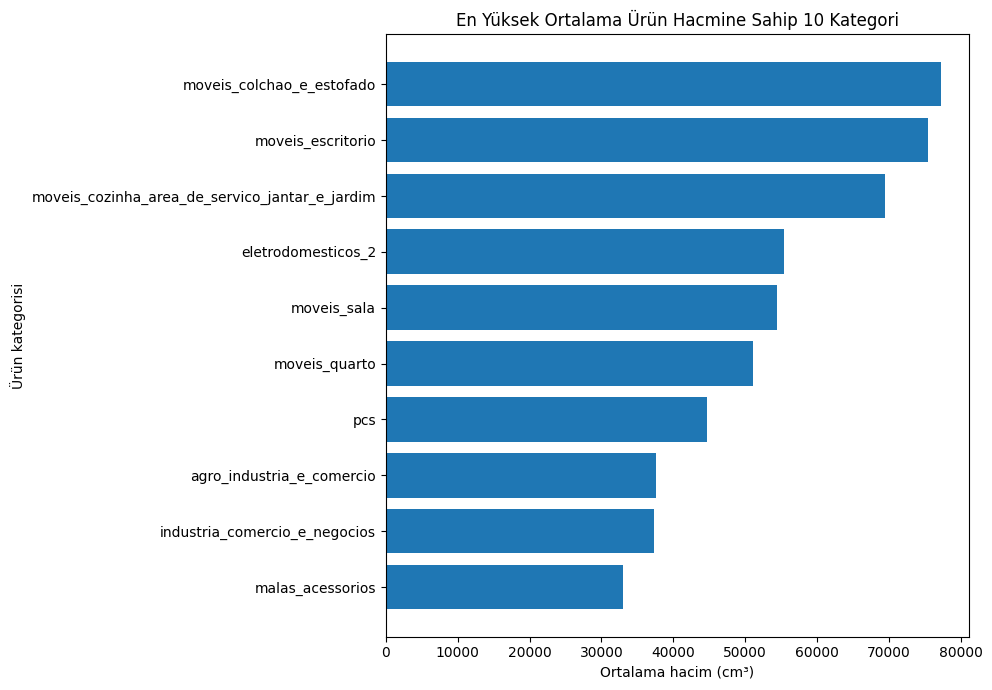

In [11]:
query = """
SELECT
    product_category,
    ROUND(
        AVG(
            product_length_cm::numeric
            * product_height_cm
            * product_width_cm
        ),
        2
    ) AS avg_volume_cm3
FROM products
WHERE product_category IS NOT NULL
  AND product_length_cm IS NOT NULL
  AND product_height_cm IS NOT NULL
  AND product_width_cm IS NOT NULL
GROUP BY product_category
ORDER BY avg_volume_cm3 DESC
LIMIT 10;
"""

df_volume = pd.read_sql_query(query, engine)

plt.figure(figsize=(10, 7))

plt.barh(
    df_volume["product_category"][::-1],
    df_volume["avg_volume_cm3"][::-1]
)

plt.xlabel("Ortalama hacim (cm³)")
plt.ylabel("Ürün kategorisi")
plt.title("En Yüksek Ortalama Ürün Hacmine Sahip 10 Kategori")

plt.tight_layout()
plt.show()

## 4. Correlation Between Freight Value and Product Characteristics

In [12]:
query = """
SELECT
    ROUND(CORR(oi.freight_value, p.product_length_cm)::numeric, 3) AS corr_length,
    ROUND(CORR(oi.freight_value, p.product_height_cm)::numeric, 3) AS corr_height,
    ROUND(CORR(oi.freight_value, p.product_width_cm)::numeric, 3) AS corr_width,
    ROUND(
        CORR(
            oi.freight_value,
            p.product_length_cm::numeric
            * p.product_height_cm
            * p.product_width_cm
        )::numeric,
        3
    ) AS corr_volume,
    ROUND(CORR(oi.freight_value, p.product_weight_grams)::numeric, 3) AS corr_weight,
    ROUND(CORR(oi.freight_value, oi.price)::numeric, 3) AS corr_price
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id;
"""

df_freight_corr = pd.read_sql_query(query, engine)

df_freight_corr

,corr_length,corr_height,corr_width,corr_volume,corr_weight,corr_price
0,0.309,0.392,0.324,0.587,0.61,0.414


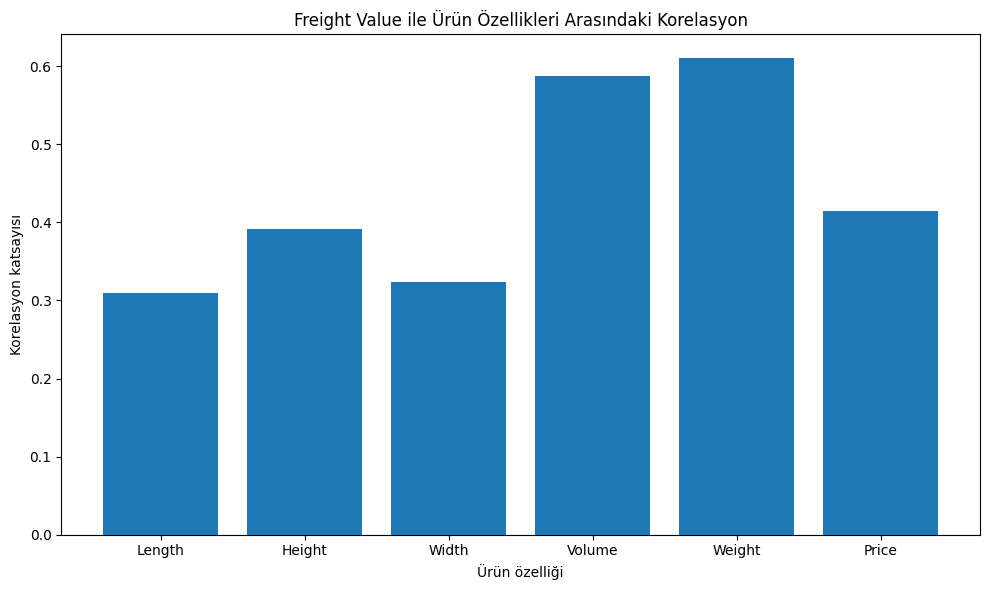

In [13]:
correlation_labels = [
    "Length",
    "Height",
    "Width",
    "Volume",
    "Weight",
    "Price"
]

correlation_values = [
    df_freight_corr.loc[0, "corr_length"],
    df_freight_corr.loc[0, "corr_height"],
    df_freight_corr.loc[0, "corr_width"],
    df_freight_corr.loc[0, "corr_volume"],
    df_freight_corr.loc[0, "corr_weight"],
    df_freight_corr.loc[0, "corr_price"]
]

plt.figure(figsize=(10, 6))

plt.bar(
    correlation_labels,
    correlation_values
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Ürün özelliği")
plt.ylabel("Korelasyon katsayısı")
plt.title("Freight Value ile Ürün Özellikleri Arasındaki Korelasyon")

plt.tight_layout()
plt.show()

## 5. Relationship Between Units Sold and Product Photo Quantity

In [14]:
query = """
WITH product_sales AS (
    SELECT
        oi.product_id,
        COUNT(*) AS units_sold
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.product_id
)
SELECT
    ps.product_id,
    ps.units_sold,
    p.product_photos_qty
FROM product_sales ps
JOIN products p
    ON ps.product_id = p.product_id
WHERE p.product_photos_qty IS NOT NULL
ORDER BY ps.units_sold DESC;
"""

df_units_photos = pd.read_sql_query(query, engine)

df_units_photos

,product_id,units_sold,product_photos_qty
0,aca2eb7d00ea1a7b8ebd4e68314663af,520,6
1,422879e10f46682990de24d770e7f83d,484,2
2,99a4788cb24856965c36a24e339b6058,477,1
3,389d119b48cf3043d311335e499d9c6b,390,2
4,368c6c730842d78016ad823897a372db,388,2
...,...,...,...
31627,a646939770b864f77ca0e16b99a8f526,1,2
31628,0a27862bbf658a5b8cf655761bc5c72d,1,1
31629,abcfceb4d3a690bb6b3887235e2854bd,1,2
31630,e6659901062c8258ead0161dec94ec0e,1,1


In [15]:
query = """
WITH product_sales AS (
    SELECT
        oi.product_id,
        COUNT(*) AS units_sold
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.product_id
)
SELECT
    ROUND(
        CORR(ps.units_sold, p.product_photos_qty)::numeric,
        3
    ) AS correlation
FROM product_sales ps
JOIN products p
    ON ps.product_id = p.product_id
WHERE p.product_photos_qty IS NOT NULL;
"""

df_units_photos_corr = pd.read_sql_query(query, engine)

df_units_photos_corr

,correlation
0,0.004


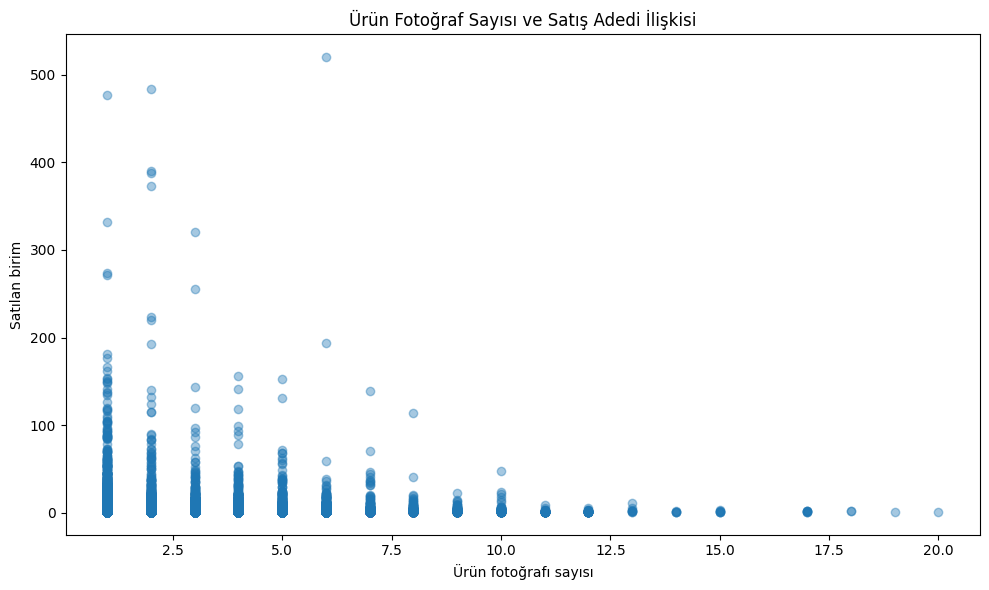

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_units_photos["product_photos_qty"],
    df_units_photos["units_sold"],
    alpha=0.4
)

plt.xlabel("Ürün fotoğrafı sayısı")
plt.ylabel("Satılan birim")
plt.title("Ürün Fotoğraf Sayısı ve Satış Adedi İlişkisi")

plt.tight_layout()
plt.show()

## 6. Linear Relationship Between Freight Value and Product Weight

In [17]:
query = """
SELECT
    ROUND(
        REGR_SLOPE(
            oi.freight_value,
            p.product_weight_grams / 1000.0
        )::numeric,
        3
    ) AS slope,
    ROUND(
        REGR_INTERCEPT(
            oi.freight_value,
            p.product_weight_grams / 1000.0
        )::numeric,
        3
    ) AS intercept
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
WHERE p.product_weight_grams IS NOT NULL
  AND oi.freight_value IS NOT NULL;
"""

df_freight_regression = pd.read_sql_query(query, engine)

df_freight_regression

,slope,intercept
0,2.572,14.606


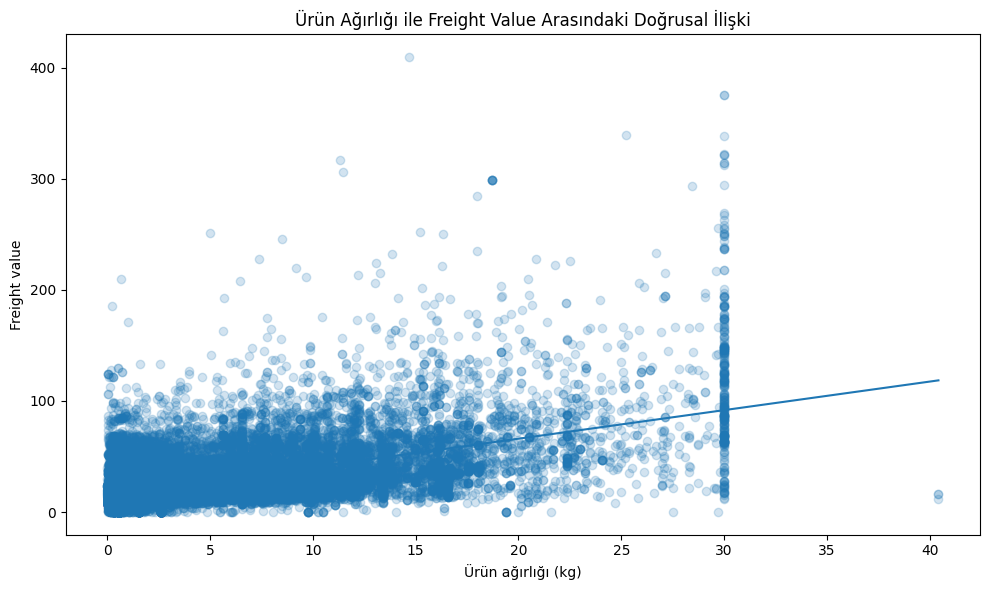

In [18]:
query = """
SELECT
    p.product_weight_grams / 1000.0 AS weight_kg,
    oi.freight_value
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
WHERE p.product_weight_grams IS NOT NULL
  AND oi.freight_value IS NOT NULL;
"""

df_freight_weight = pd.read_sql_query(query, engine)

plt.figure(figsize=(10, 6))

plt.scatter(
    df_freight_weight["weight_kg"],
    df_freight_weight["freight_value"],
    alpha=0.2
)

slope = df_freight_regression.loc[0, "slope"]
intercept = df_freight_regression.loc[0, "intercept"]

x_values = [
    df_freight_weight["weight_kg"].min(),
    df_freight_weight["weight_kg"].max()
]

y_values = [
    intercept + slope * x
    for x in x_values
]

plt.plot(x_values, y_values)

plt.xlabel("Ürün ağırlığı (kg)")
plt.ylabel("Freight value")
plt.title("Ürün Ağırlığı ile Freight Value Arasındaki Doğrusal İlişki")

plt.tight_layout()
plt.show()

In [19]:
engine.dispose()